In [36]:
import pandas as pd
import numpy as np
import networkx as nx

from rdkit import Chem
import matplotlib.pyplot as plt
%matplotlib inline


from torch_geometric.data import Data
from torch_geometric.transforms import RandomLinkSplit
import torch_geometric.transforms as T

import torch
import torch.nn.functional as F
from torch.optim.lr_scheduler import MultiplicativeLR

from sklearn.metrics import roc_auc_score ,auc,precision_recall_curve

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from flashtext import KeywordProcessor

import re



# Process Data

## Graph Data

In [37]:
DDI_graph = pd.read_csv('https://raw.githubusercontent.com/liiniix/BioSNAP/master/ChCh-Miner/ChCh-Miner_durgbank-chem-chem.tsv', sep='\t')
DDI_graph.rename(columns={'Drug1': 'src', 'Drug2': 'dst'}, inplace=True)
DrugIDs_in_graph = np.unique(DDI_graph.values) # there are 1514 unique drugs in the graph

G = nx.from_pandas_edgelist(DDI_graph, 'src', 'dst')

## SMILES Data


In [38]:
drugsSMILES = pd.read_csv('https://raw.githubusercontent.com/sshaghayeghs/molSMILES/main/structure%20links%202.csv')
drugID_smiles = drugsSMILES[["DrugBank ID", "SMILES"]]
drugID_smiles.dropna(inplace=True)
drugID_smiles.reset_index(drop=True, inplace=True)

/tmp/ipykernel_707314/706743108.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



## Description Data

In [39]:
drugsDESC = pd.read_csv('https://raw.githubusercontent.com/sshaghayeghs/molSMILES/main/Drug_description.csv')
drugID_DESC = drugsDESC[["Drug ID", "Discription"]]
drugID_DESC.dropna(inplace=True)
drugID_DESC.reset_index(drop=True, inplace=True)

/tmp/ipykernel_707314/1344816557.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



## Description Embeddings

In [41]:
# Load embeddings (assuming first column is DrugBank ID)
embeddings_df = pd.read_csv('/data/giobbi/embeddings/Dr_Desc_GPT.csv', sep='\t', index_col=0)
if 'Unnamed: 0' in embeddings_df.columns:
    embeddings_df = embeddings_df.drop(columns='Unnamed: 0')

# Filter to drugs in your graph (optional, if not already done)
embeddings_df = embeddings_df[embeddings_df.iloc[:, 0].isin(DrugIDs_in_graph)].reset_index(drop=True)



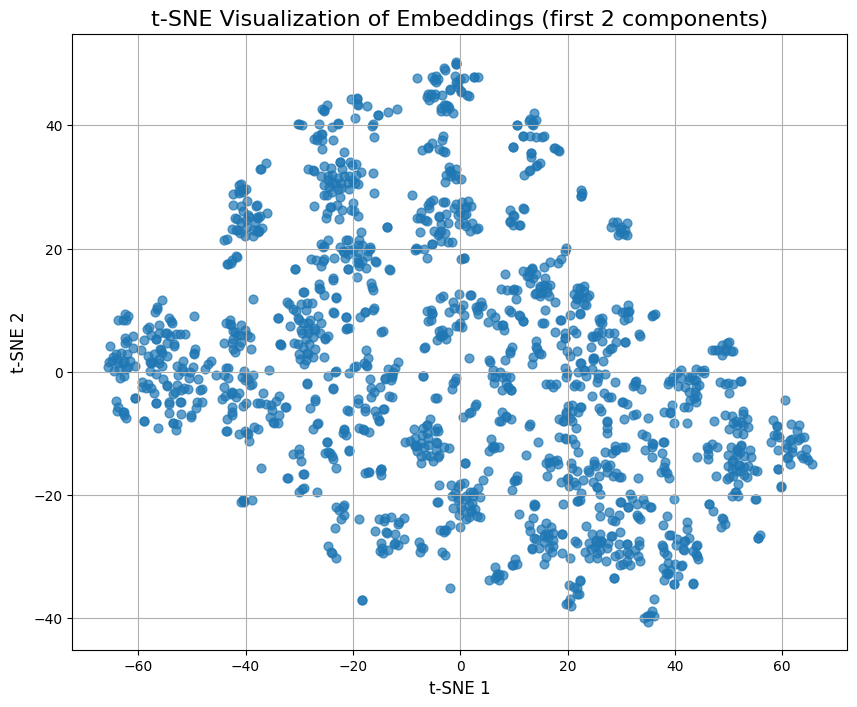

In [42]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Select only numeric columns for t-SNE
embeddings_numeric = embeddings_df.select_dtypes(include=['float64', 'int64'])

# Apply t-SNE for 2D visualization
tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings_numeric)

# Plot the result
plt.figure(figsize=(10, 8))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.7, s=40)
plt.title('t-SNE Visualization of Embeddings (first 2 components)', fontsize=16)
plt.xlabel('t-SNE 1', fontsize=12)
plt.ylabel('t-SNE 2', fontsize=12)
plt.grid(True)
plt.show()

# Sync Datasets

In [43]:
#checking if a molecule has a valid molecule corespodn to the smiles string
def is_valid_molecule(smiles) -> bool:
    try:
        mol = Chem.MolFromSmiles(smiles)
        return mol is not None
    except:
        return False

In [44]:
valid_smiles = pd.DataFrame(drugID_smiles)
valid_smiles['IsValidMolecule'] = drugID_smiles['SMILES'].apply(is_valid_molecule)
df_valid_molecules = valid_smiles[valid_smiles['IsValidMolecule']]

# Drop the temporary 'IsValidMolecule' column
df_valid_molecules = df_valid_molecules.drop(columns=['IsValidMolecule'])

[15:12:07] Explicit valence for atom # 13 Cl, 5, is greater than permitted
[15:12:07] SMILES Parse Error: syntax error while parsing: OS(O)(O)C1=CC=C(C=C1)C-1=C2\C=CC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC=C(C=C1)S(O)(O)O)C1=CC=C(C=C1)S([O-])([O-])[O-])\C1=CC=C(C=C1)S(O)(O)[O-]
[15:12:07] SMILES Parse Error: check for mistakes around position 84:
[15:12:07] C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC=C(C=C1)S(O
[15:12:07] ~~~~~~~~~~~~~~~~~~~~^
[15:12:07] SMILES Parse Error: extra open parentheses while parsing: OS(O)(O)C1=CC=C(C=C1)C-1=C2\C=CC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC=C(C=C1)S(O)(O)O)C1=CC=C(C=C1)S([O-])([O-])[O-])\C1=CC=C(C=C1)S(O)(O)[O-]
[15:12:07] SMILES Parse Error: check for mistakes around position 40:
[15:12:07] 1)C-1=C2\C=CC(=N2)\C(=C2/N\C(\C=C2)=C(/C2
[15:12:07] ~~~~~~~~~~~~~~~~~~~~^
[15:12:07] SMILES Parse Error: extra open parentheses while parsing: OS(O)(O)C1=CC=C(C=C1)C-1=C2\C=CC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C

In [45]:

allowed_drug=[list(df_valid_molecules['DrugBank ID']),list(drugID_DESC['Drug ID'])]
# There are 1278 drugIDs that occur in the graph. Some graph nodes do not have associated SMILES or drug description

#droping the links that do not have any SMILES
for l in allowed_drug:
  for index, row in DDI_graph.iterrows():
      # Check if both cells in the row are in the allowed cells list
      if row['src'] not in l or row['dst'] not in l:
          #b If either cell is not in the allowed cells list, remove the row
          DDI_graph.drop(index, inplace=True)



In [46]:
#27800 edges
DDI_graph=DDI_graph.reset_index(drop=True)


In [47]:
#save the drugs smiles and drug description in the networks into a new dataframe
drugID_smiles_ddi = drugID_smiles[drugID_smiles['DrugBank ID'].isin(list(np.unique(DDI_graph.values)))]
drugID_smiles_ddi=drugID_smiles_ddi.reset_index(drop=True)
drugID_DESC_ddi = drugID_DESC[drugID_DESC['Drug ID'].isin(list(np.unique(DDI_graph.values)))]
drugID_DESC_ddi=drugID_DESC_ddi.reset_index(drop=True)

In [48]:
drugID_DESC_ddi = drugID_DESC_ddi.merge(
    embeddings_df,
    left_on='Drug ID',
    right_on=embeddings_df.columns[0],
    how='left',
    suffixes=('', '_emb')  # Add suffix to right columns
)

# Drop the right-side 'Discription_emb' column if it exists
if 'Discription_emb' in drugID_DESC_ddi.columns:
    drugID_DESC_ddi = drugID_DESC_ddi.drop(columns=['Discription_emb'])

In [50]:
drugID_DESC_ddi

,Drug ID,Discription,Drug Name,0,1,2,3,4,5,6,...,1526,1527,1528,1529,1530,1531,1532,1533,1534,1535
0,DB00006,Bivalirudin is a synthetic 20 residue peptide ...,Bivalirudin,-0.052239,-0.017372,-0.010294,0.013598,0.012951,0.020629,-0.033573,...,0.026815,-0.011329,0.064693,-0.030357,-0.016555,-0.006056,-0.014620,-0.018462,-0.018503,-0.003945
1,DB00007,Leuprolide is a synthetic 9-residue peptide an...,Leuprolide,-0.034646,0.006205,-0.005811,-0.013125,-0.000876,0.008337,-0.007728,...,0.023905,-0.038248,0.037533,-0.006168,-0.004536,0.008099,-0.004135,-0.017455,0.003576,-0.015787
2,DB00014,"Goserelin is a synthetic hormone. In men, it s...",Goserelin,-0.026568,-0.009071,-0.006254,-0.018524,-0.008834,0.027832,-0.017668,...,0.037311,-0.018024,0.018603,-0.016997,-0.047475,-0.015707,-0.012251,0.001094,0.006859,-0.005990
3,DB00035,"Desmopressin (dDAVP), a synthetic analogue of ...",Desmopressin,-0.038166,0.002665,-0.002899,-0.025053,-0.009016,0.047384,-0.012325,...,0.022035,-0.003084,0.047870,-0.017708,-0.018194,0.011011,-0.022695,-0.035336,-0.020107,0.013841
4,DB00080,Daptomycin is a cyclic lipopeptide antibacteri...,Daptomycin,-0.013412,-0.020330,-0.009596,-0.035396,-0.014272,0.061586,-0.014272,...,-0.006389,-0.019219,0.022923,-0.009385,-0.029550,0.024153,0.001447,-0.007434,-0.015502,0.000015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1318,DB11248,Zinc gluconate is a zinc salt of gluconic acid...,Zinc gluconate,-0.006905,0.012249,0.018780,-0.032681,0.003772,0.017360,-0.007693,...,0.005992,-0.018999,0.035004,-0.010978,-0.012565,-0.008383,-0.019787,-0.017773,-0.007241,-0.013294
1319,DB11256,Levomefolic acid (INN) is the metabolite of fo...,Levomefolic acid,0.008250,-0.009065,-0.017017,-0.010896,-0.035432,0.020886,-0.027098,...,0.020007,-0.010592,0.021469,0.002777,-0.037891,0.008767,-0.009266,-0.019541,-0.009039,-0.012462
1320,DB11315,Methscopolamine is a quaternary ammonium deriv...,Methscopolamine,-0.004351,0.016622,0.010122,-0.032811,-0.016689,0.053594,-0.013892,...,0.019770,-0.029675,0.040675,-0.009507,-0.021635,-0.002025,-0.023554,-0.022878,-0.010662,-0.023324
1321,DB00873,;;;;,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


drugID_DESC_ddi # 1323 drugs with description
drugID_smiles_ddi # 1323 drugs with smiles
DDI_graph # interaction graph with ? nodes and 41639 edges

# Analyze Drug Description

In [13]:
drugsDESC_masked = drugID_DESC_ddi.copy()
drug_list = drugsDESC['Drug Name'].to_list()
drug_ID_list = drugsDESC_masked['Drug ID'].to_list()

# Build processor
kp = KeywordProcessor(case_sensitive=False)
for drug in drug_list:
    kp.add_keyword(drug, "<DRUG>")
for drug_ID in drug_ID_list:
    kp.add_keyword(drug_ID, "<DRUG>")



# Replace & count
drugsDESC_masked['Description_Masked'] = drugsDESC_masked['Discription'].apply(kp.replace_keywords)
drugsDESC_masked['drug_unique_count'] = drugsDESC_masked['Discription'].apply(
    lambda x: len(kp.extract_keywords(x))
)

drugsDESC_masked.sort_valddues(by='drug_unique_count', ascending=False, inplace=True)

AttributeError: 'DataFrame' object has no attribute 'sort_valddues'

In [ ]:
drugsDESC_masked = drugID_DESC_ddi.copy()
drug_list = drugsDESC['Drug Name'].to_list()
drug_ID_list = drugsDESC_masked['Drug ID'].to_list()

# Build processor
kp = KeywordProcessor(case_sensitive=False)
for drug in drug_list:
    kp.add_keyword(drug, drug)
for drug_ID in drug_ID_list:
    kp.add_keyword(drug_ID, drug_ID)

# Replace & count unique drug mentions
def unique_drug_unique_count(description):
    return len(set(kp.extract_keywords(description))) if pd.notnull(description) else 0

drugsDESC_masked['Description_Masked'] = drugsDESC_masked['Discription'].apply(kp.replace_keywords)
drugsDESC_masked['drug_count'] = drugsDESC_masked['Discription'].apply(lambda x: len(kp.extract_keywords(x)))
drugsDESC_masked['drug_unique_count'] = drugsDESC_masked['Discription'].apply(unique_drug_count)

In [14]:
drugsDESC_masked

,Drug ID,Discription,Drug Name,0,1,2,3,4,5,6,...,1528,1529,1530,1531,1532,1533,1534,1535,Description_Masked,drug_unique_count
0,DB00006,Bivalirudin is a synthetic 20 residue peptide ...,Bivalirudin,-0.052239,-0.017372,-0.010294,0.013598,0.012951,0.020629,-0.033573,...,0.064693,-0.030357,-0.016555,-0.006056,-0.014620,-0.018462,-0.018503,-0.003945,<DRUG> is a synthetic 20 residue peptide (<DRU...,5
1,DB00007,Leuprolide is a synthetic 9-residue peptide an...,Leuprolide,-0.034646,0.006205,-0.005811,-0.013125,-0.000876,0.008337,-0.007728,...,0.037533,-0.006168,-0.004536,0.008099,-0.004135,-0.017455,0.003576,-0.015787,<DRUG> is a synthetic 9-residue peptide analog...,4
2,DB00014,"Goserelin is a synthetic hormone. In men, it s...",Goserelin,-0.026568,-0.009071,-0.006254,-0.018524,-0.008834,0.027832,-0.017668,...,0.018603,-0.016997,-0.047475,-0.015707,-0.012251,0.001094,0.006859,-0.005990,"<DRUG> is a synthetic hormone. In men, it stop...",4
3,DB00035,"Desmopressin (dDAVP), a synthetic analogue of ...",Desmopressin,-0.038166,0.002665,-0.002899,-0.025053,-0.009016,0.047384,-0.012325,...,0.047870,-0.017708,-0.018194,0.011011,-0.022695,-0.035336,-0.020107,0.013841,"<DRUG> (dDAVP), a synthetic analogue of 8-<DRU...",7
4,DB00080,Daptomycin is a cyclic lipopeptide antibacteri...,Daptomycin,-0.013412,-0.020330,-0.009596,-0.035396,-0.014272,0.061586,-0.014272,...,0.022923,-0.009385,-0.029550,0.024153,0.001447,-0.007434,-0.015502,0.000015,<DRUG> is a cyclic lipopeptide antibacterial a...,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1318,DB11248,Zinc gluconate is a zinc salt of gluconic acid...,Zinc gluconate,-0.006905,0.012249,0.018780,-0.032681,0.003772,0.017360,-0.007693,...,0.035004,-0.010978,-0.012565,-0.008383,-0.019787,-0.017773,-0.007241,-0.013294,<DRUG> is a <DRUG> salt of <DRUG> comprised of...,6
1319,DB11256,Levomefolic acid (INN) is the metabolite of fo...,Levomefolic acid,0.008250,-0.009065,-0.017017,-0.010896,-0.035432,0.020886,-0.027098,...,0.021469,0.002777,-0.037891,0.008767,-0.009266,-0.019541,-0.009039,-0.012462,<DRUG> (INN) is the metabolite of <DRUG> (Vita...,9
1320,DB11315,Methscopolamine is a quaternary ammonium deriv...,Methscopolamine,-0.004351,0.016622,0.010122,-0.032811,-0.016689,0.053594,-0.013892,...,0.040675,-0.009507,-0.021635,-0.002025,-0.023554,-0.022878,-0.010662,-0.023324,<DRUG> is a quaternary ammonium derivative of ...,3
1321,DB00873,;;;;,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,;;;;,0


In [15]:
# pharma_class column

# Define keyword lists for each class
keyword_classes = {
    0: [  # Antidepressants
        "antidepressant", "tricyclic", "tca", "ssri", "snri", "maoi", "serotonin", "norepinephrine reuptake"
    ],
    1: [  # Antifungals
        "antifungal", "azole", "ergosterol", "ketoconazole", "fluconazole", "itraconazole", "voriconazole"
    ],
    2: [  # Antihypertensives
        "antihypertensive", "hypertension", "angiotensin ii receptor blocker", "arb",
        "ace inhibitor", "calcium channel blocker", "ccb", "beta-blocker"
    ],
    3: [  # Antibiotics
        "antibiotic", "macrolide", "penicillin", "cephalosporin", "fluoroquinolone", "tetracycline", "bacterial infections"
    ],
    4: [  # Antivirals
        "antiviral", "protease inhibitor", "reverse transcriptase inhibitor", "integrase inhibitor",
        "hiv", "hepatitis", "influenza"
    ],
    5: [  # Anticancer (chemotherapy / oncology)
        "antineoplastic", "chemotherapy", "kinase inhibitor", "monoclonal antibody", "cytotoxic"
    ],
    6: [  # Analgesics / Pain management
        "analgesic", "opioid", "nsaid", "pain"
    ],
    7: [  # Antidiabetics
        "antidiabetic", "insulin", "glp-1", "sglt2 inhibitor", "metformin", "diabetes"
    ],
    8: [  # Gastrointestinal / Acid-related
        "proton pump inhibitor", "ppi", "h2 receptor antagonist", "gerd", "ulcer"
    ]
}


def assign_class(description):
    if pd.isnull(description):
        return 9  # None of the keywords
    desc = description.lower()
    for class_idx, keywords in keyword_classes.items():
        for kw in keywords:
            # For "azole" match as word ending, otherwise substring
            if kw == "azole":
                if re.search(r"\w+azole\b", desc):
                    return class_idx
            elif kw in desc:
                return class_idx
    return 9  # None of the keywords

# Assign class integer to each row
drugsDESC_masked['pharma_class'] = drugsDESC_masked['Discription'].apply(assign_class)

# Optional: check class distribution
print(drugsDESC_masked['pharma_class'].value_counts())

pharma_class
9    712
2    149
3    107
6     90
0     64
5     63
4     49
1     47
7     25
8     17
Name: count, dtype: int64


In [17]:
import pandas as pd
import re

# Expanded keyword dictionary
keyword_classes = {
    0: [  # Antidepressants
        "antidepressant", "tricyclic", "tca", "ssri", "snri", "maoi",
        "serotonin reuptake", "norepinephrine reuptake", "sertraline",
        "fluoxetine", "paroxetine", "citalopram", "escitalopram", "venlafaxine",
        "duloxetine", "mirtazapine", "bupropion"
    ],
    1: [  # Antifungals
        "antifungal", "azole", "ergosterol", "ketoconazole", "fluconazole",
        "itraconazole", "voriconazole", "posaconazole", "amphotericin",
        "echinocandin", "caspofungin", "micafungin", "anidulafungin"
    ],
    2: [  # Antihypertensives
        "antihypertensive", "hypertension", "blood pressure", "angiotensin",
        "arb", "ace inhibitor", "calcium channel blocker", "ccb", "beta-blocker",
        "losartan", "valsartan", "amlodipine", "lisinopril", "enalapril",
        "atenolol", "metoprolol", "propranolol"
    ],
    3: [  # Antibiotics
        "antibiotic", "antibacterial", "macrolide", "penicillin", "amoxicillin",
        "ampicillin", "cephalosporin", "ceftriaxone", "cephalexin",
        "fluoroquinolone", "ciprofloxacin", "levofloxacin", "tetracycline",
        "doxycycline", "minocycline", "clindamycin", "azithromycin",
        "erythromycin", "bacterial infection"
    ],
    4: [  # Antivirals
        "antiviral", "protease inhibitor", "reverse transcriptase inhibitor",
        "integrase inhibitor", "hiv", "hepatitis", "influenza", "acyclovir",
        "valacyclovir", "oseltamivir", "remdesivir", "sofosbuvir"
    ],
    5: [  # Anticancer
        "antineoplastic", "chemotherapy", "kinase inhibitor",
        "monoclonal antibody", "cytotoxic", "oncology", "immunotherapy",
        "platinum-based", "cisplatin", "carboplatin", "paclitaxel", "docetaxel",
        "bevacizumab", "trastuzumab", "rituximab"
    ],
    6: [  # Analgesics
        "analgesic", "pain", "painkiller", "opioid", "morphine", "oxycodone",
        "hydrocodone", "fentanyl", "codeine", "nsaid", "ibuprofen",
        "naproxen", "diclofenac", "acetaminophen", "paracetamol"
    ],
    7: [  # Antidiabetics
        "antidiabetic", "diabetes", "insulin", "glp-1", "glp1",
        "sglt2 inhibitor", "metformin", "sulfonylurea", "glipizide",
        "glyburide", "pioglitazone", "rosiglitazone", "dapagliflozin",
        "empagliflozin", "liraglutide", "semaglutide"
    ],
    8: [  # Gastrointestinal
        "gastrointestinal", "proton pump inhibitor", "ppi",
        "omeprazole", "lansoprazole", "pantoprazole", "rabeprazole",
        "esomeprazole", "h2 receptor antagonist", "ranitidine",
        "famotidine", "cimetidine", "gerd", "acid reflux", "ulcer"
    ],
    9: [  # Corticosteroids / Anti-inflammatory
        "corticosteroid", "glucocorticoid", "steroid", 
        "prednisone", "prednisolone", "methylprednisolone", 
        "dexamethasone", "hydrocortisone", "betamethasone"
    ],
    10: [  # Hormonal / Endocrine therapy
        "estrogen", "estradiol", "estriol", "estrone", 
        "progesterone", "progestin", "contraceptive", "birth control",
        "hormone replacement", "hrt", "tamoxifen", "raloxifene",
        "clomiphene", "letrozole", "aromatase inhibitor"
    ],
    11: [  # Sedatives / Hypnotics / Anxiolytics
        "benzodiazepine", "benzo", "diazepam", "valium", 
        "lorazepam", "ativan", "alprazolam", "xanax", "clonazepam",
        "temazepam", "zolpidem", "z-drug", "eszopiclone", "lunesta",
        "zaleplon", "sleep", "insomnia", "hypnotic", "sedative",
        "anxiolytic", "buspirone", "ramelteon", "melatonin"
    ],
    12: [  # Respiratory (Asthma / COPD)
        "asthma", "copd", "bronchodilator", "inhaler", "inhaled corticosteroid",
        "beta-agonist", "saba", "laba", "albuterol", "salbutamol", "ventolin",
        "formoterol", "salmeterol", "terbutaline",
        "fluticasone", "budesonide", "beclomethasone", "mometasone",
        "tiotropium", "ipratropium", "anticholinergic inhaler",
        "montelukast", "leukotriene antagonist"
    ],
    13: [  # Contrast Agents (Radiology / Imaging)
        "contrast agent", "radiopaque", "iodinated contrast", "iodine contrast",
        "gadolinium", "mri contrast", "ct contrast", "iohexol", "iopamidol",
        "iopromide", "gadobutrol", "gadoterate", "gadodiamide", "ultrasound contrast",
        "microbubble"
    ],
    14: [  # Antipsychotics
        "antipsychotic", "neuroleptic", "schizophrenia", "bipolar disorder",
        "haloperidol", "chlorpromazine", "fluphenazine",  # typical
        "risperidone", "olanzapine", "quetiapine", "clozapine",
        "aripiprazole", "ziprasidone", "paliperidone", "lurasidone", "asenapine",  # atypical
        "dopamine antagonist", "serotonin dopamine antagonist"
    ],
    15: [  # Antimalarials
        "antimalarial", "malaria", "plasmodium", "chloroquine", "hydroxychloroquine",
        "mefloquine", "quinine", "artemisinin", "artemether", "lumefantrine",
        "atovaquone", "proguanil", "primaquine", "tafenoquine"
    ],
    16: [  # Antiparasitics (non-malarial)
        "antiparasitic", "helminth", "protozoa", "ivermectin", "albendazole",
        "mebendazole", "praziquantel", "metronidazole", "tinidazole"
    ],
    17: [  # Antiepileptics / Anticonvulsants
        "antiepileptic", "anticonvulsant", "seizure", "epilepsy",
        "valproate", "valproic acid", "carbamazepine", "phenytoin",
        "lamotrigine", "levetiracetam", "topiramate", "gabapentin", "pregabalin"
    ],
    18: [  # Immunosuppressants
        "immunosuppressant", "transplant", "cyclosporine", "tacrolimus",
        "sirolimus", "everolimus", "mycophenolate", "azathioprine"
    ],
    19: [  # Anticoagulants / Antiplatelets
        "anticoagulant", "blood thinner", "warfarin", "heparin", "enoxaparin",
        "apixaban", "rivaroxaban", "dabigatran", "clopidogrel", "ticagrelor",
        "aspirin"
    ],
    20: [  # Lipid-lowering agents
        "lipid-lowering", "cholesterol", "statin", "atorvastatin", "simvastatin",
        "rosuvastatin", "pravastatin", "lovastatin", "ezetimibe",
        "pcsk9 inhibitor", "alirocumab", "evolocumab"
    ],
    21: [  # Thyroid drugs
        "thyroid", "hypothyroid", "hyperthyroid", "levothyroxine", "liothyronine",
        "methimazole", "propylthiouracil"
    ],
    22: [  # Vitamins & Supplements
        "vitamin", "supplement", "vitamin d", "vitamin b12", "folic acid",
        "iron", "calcium", "magnesium", "zinc", "multivitamin"
    ],
    23: [  # Unknown / None
    ],
    24: [  # Antiallergics / Antihistamines
        "antiallergic", "antihistamine", "loratadine", "cetirizine",
        "fexofenadine", "diphenhydramine", "chlorpheniramine", 
        "desloratadine", "allergy"
    ],
    25: [  # Anesthetics
        "anesthetic", "anesthesia", "lidocaine", "bupivacaine", 
        "propofol", "ketamine", "sevoflurane", "desflurane", 
        "general anesthesia", "local anesthesia", "spinal anesthesia"
    ],
    26: [  # Headache / Migraine
        "migraine", "headache", "triptan", "sumatriptan", "rizatriptan",
        "eletriptan", "naratriptan", "almotriptan", "frovatriptan",
        "acetaminophen", "paracetamol", "ibuprofen", "naproxen"
    ],
    27: [  # Bladder / Urinary
        "bladder", "urinary", "overactive bladder", "oxybutynin", 
        "tolterodine", "solifenacin", "darifenacin", "mirabegron",
        "tamsulosin", "benign prostatic hyperplasia", "bph"
    ],
    28: [  # Cancer / Leukemia
        "leukemia", "lymphoma", "multiple myeloma", "acute lymphoblastic",
        "acute myeloid", "chronic myeloid", "imatinib", "dasatinib",
        "nilotinib", "rituximab", "blinatumomab", "chemotherapy",
        "oncology", "cytotoxic"
    ],
}

def assign_class(description):
    if pd.isnull(description):
        return 23  # Unknown / None

    desc = description.lower()
    class_counts = {i: 0 for i in keyword_classes}

    for class_idx, keywords in keyword_classes.items():
        for kw in keywords:
            if kw == "azole":  # special case: match suffix
                if re.search(r"\w+azole\b", desc):
                    class_counts[class_idx] += 1
            elif kw in desc:
                class_counts[class_idx] += 1

    # Choose the class with the highest count
    best_class = max(class_counts, key=class_counts.get)
    if class_counts[best_class] == 0:
        return 23 # No matches
    return best_class

# Apply classification
drugsDESC_masked['pharma_class'] = drugsDESC_masked['Discription'].apply(assign_class)

# Check distribution
print(drugsDESC_masked['pharma_class'].value_counts())

pharma_class
23    259
2     128
3     126
6      86
11     68
5      59
9      58
4      50
22     47
0      43
14     38
12     37
17     36
1      34
8      32
10     30
28     27
25     24
7      23
19     20
27     19
15     16
20     16
26     13
24     10
21      9
18      8
13      6
16      1
Name: count, dtype: int64


In [18]:
class_labels = [
    'Antidepressants',               # 0
    'Antifungals',                   # 1
    'Antihypertensives',             # 2
    'Antibiotics',                   # 3
    'Antivirals',                    # 4
    'Anticancer',                    # 5
    'Analgesics',                    # 6
    'Antidiabetics',                 # 7
    'GI/Acid-related',               # 8
    'Corticosteroids',               # 9
    'Hormonal / Endocrine',          # 10
    'Sedatives / Hypnotics / Anxiolytics',  # 11
    'Respiratory (Asthma / COPD)',   # 12
    'Contrast Agents',               # 13
    'Antipsychotics',                # 14
    'Antimalarials',                 # 15
    'Antiparasitics (non-malarial)', # 16
    'Antiepileptics / Anticonvulsants', # 17
    'Immunosuppressants',            # 18
    'Anticoagulants / Antiplatelets',# 19
    'Lipid-lowering agents',         # 20
    'Thyroid drugs',                 # 21
    'Vitamins & Supplements',        # 22
    'None/Other',                    # 23
    'Antiallergics / Antihistamines', # 24
    'Anesthetics / Anesthesia',       # 25
    'Headache / Migraine',            # 26
    'Bladder / Urinary',              # 27
    'Cancer / Leukemia specific'      # 28
]

In [19]:
drugsDESC_masked['pharma_class']

0        2
1        9
2       10
3       23
4        3
        ..
1318    22
1319    22
1320     8
1321    23
1322    27
Name: pharma_class, Length: 1323, dtype: int64

# Visualize Embedding

## Apply t-SNE for Dimensionality Reduction
Use sklearn.manifold.TSNE to reduce the embeddings to 2D or 3D.

In [20]:
from sklearn.manifold import TSNE

In [21]:
# Apply t-SNE for Dimensionality Reduction

drugsDESC_masked.dropna(inplace=True)
drug_embeddings = drugsDESC_masked.select_dtypes(include=['float64'])

# Initialize t-SNE with 2 components for 2D visualization
tsne = TSNE(n_components=2 ) #, random_state=42) # 42

# Apply t-SNE to the drug embeddings
reduced_embeddings = tsne.fit_transform(drug_embeddings)

# Convert the reduced embeddings to a DataFrame for easier handling
reduced_embeddings_df = pd.DataFrame(reduced_embeddings, columns=['TSNE-1', 'TSNE-2'])


# Visualize t-SNE Results with Matplotlib
Plot the 2D t-SNE results using matplotlib's scatter plot.

In [22]:
marker_size = 8

In [23]:
import plotly.express as px

fig = px.scatter(
reduced_embeddings_df,
x='TSNE-1',
y='TSNE-2',
color=drugsDESC_masked['drug_unique_count'],
color_continuous_scale='mygbm',
hover_data={
'Drug Name': drugsDESC_masked.get('Drug Name', None),
#'Discription': drugsDESC_masked['Discription'],
'drug_unique_count': drugsDESC_masked['drug_unique_count']
},
title='Interactive t-SNE Visualization of Drug Embeddings'
)

# Make markers larger
fig.update_traces(marker=dict(size=marker_size))

fig.update_layout(
coloraxis_colorbar=dict(
title='Unique Drug Count in Description'
),
width=900,
height=700
)

fig.show()

In [25]:
drugsDESC_masked   


,Drug ID,Discription,Drug Name,0,1,2,3,4,5,6,...,1529,1530,1531,1532,1533,1534,1535,Description_Masked,drug_unique_count,pharma_class
0,DB00006,Bivalirudin is a synthetic 20 residue peptide ...,Bivalirudin,-0.052239,-0.017372,-0.010294,0.013598,0.012951,0.020629,-0.033573,...,-0.030357,-0.016555,-0.006056,-0.014620,-0.018462,-0.018503,-0.003945,<DRUG> is a synthetic 20 residue peptide (<DRU...,5,2
1,DB00007,Leuprolide is a synthetic 9-residue peptide an...,Leuprolide,-0.034646,0.006205,-0.005811,-0.013125,-0.000876,0.008337,-0.007728,...,-0.006168,-0.004536,0.008099,-0.004135,-0.017455,0.003576,-0.015787,<DRUG> is a synthetic 9-residue peptide analog...,4,9
2,DB00014,"Goserelin is a synthetic hormone. In men, it s...",Goserelin,-0.026568,-0.009071,-0.006254,-0.018524,-0.008834,0.027832,-0.017668,...,-0.016997,-0.047475,-0.015707,-0.012251,0.001094,0.006859,-0.005990,"<DRUG> is a synthetic hormone. In men, it stop...",4,10
3,DB00035,"Desmopressin (dDAVP), a synthetic analogue of ...",Desmopressin,-0.038166,0.002665,-0.002899,-0.025053,-0.009016,0.047384,-0.012325,...,-0.017708,-0.018194,0.011011,-0.022695,-0.035336,-0.020107,0.013841,"<DRUG> (dDAVP), a synthetic analogue of 8-<DRU...",7,23
4,DB00080,Daptomycin is a cyclic lipopeptide antibacteri...,Daptomycin,-0.013412,-0.020330,-0.009596,-0.035396,-0.014272,0.061586,-0.014272,...,-0.009385,-0.029550,0.024153,0.001447,-0.007434,-0.015502,0.000015,<DRUG> is a cyclic lipopeptide antibacterial a...,11,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1317,DB11181,Homatropine is an anticholinergic drug that ac...,Homatropine,-0.020102,0.022434,0.004982,-0.007116,-0.008141,0.034737,0.000306,...,-0.001187,-0.008711,-0.002524,-0.019365,-0.002332,0.003813,-0.009750,<DRUG> is an anticholinergic drug that acts as...,6,6
1318,DB11248,Zinc gluconate is a zinc salt of gluconic acid...,Zinc gluconate,-0.006905,0.012249,0.018780,-0.032681,0.003772,0.017360,-0.007693,...,-0.010978,-0.012565,-0.008383,-0.019787,-0.017773,-0.007241,-0.013294,<DRUG> is a <DRUG> salt of <DRUG> comprised of...,6,22
1319,DB11256,Levomefolic acid (INN) is the metabolite of fo...,Levomefolic acid,0.008250,-0.009065,-0.017017,-0.010896,-0.035432,0.020886,-0.027098,...,0.002777,-0.037891,0.008767,-0.009266,-0.019541,-0.009039,-0.012462,<DRUG> (INN) is the metabolite of <DRUG> (Vita...,9,22
1320,DB11315,Methscopolamine is a quaternary ammonium deriv...,Methscopolamine,-0.004351,0.016622,0.010122,-0.032811,-0.016689,0.053594,-0.013892,...,-0.009507,-0.021635,-0.002025,-0.023554,-0.022878,-0.010662,-0.023324,<DRUG> is a quaternary ammonium derivative of ...,3,8


In [26]:
import plotly.express as px
import numpy as np

# Bin drug_count: separate bin for count 1, then bins for higher counts
drug_count = drugsDESC_masked['drug_unique_count']
max_count = drug_count.max()
bins = [0, 1, 2, 5, 10, 20]
if max_count > 20:
    bins.append(max_count + 1)
# Ensure bin edges are unique and sorted
bins = sorted(set(bins))
labels = ['1', '2-4', '5-9', '10-19', '20+', f'>{20}' if max_count > 20 else f'{max_count}']
# Assign bin labels: count==1 gets '1', others get appropriate bin
drug_count_binned = pd.cut(drug_count, bins=bins, labels=labels[:len(bins)-1], right=False)

# Use a valid qualitative color sequence for discrete bins
color_sequence = px.colors.qualitative.Set1

# Create an interactive scatter plot with Plotly using binned drug_count
fig = px.scatter(
    reduced_embeddings_df,
    x='TSNE-1',
    y='TSNE-2',
    color=drug_count_binned,
    color_discrete_sequence=color_sequence,
    hover_data={
        'Drug Name': drugsDESC_masked.get('Drug Name', None),
        #'Discription': drugsDESC_masked['Discription'],
        'drug_count': drugsDESC_masked['drug_unique_count']
    },
    title='Interactive t-SNE Visualization of Drug Embeddings (Binned Drug Count)'
)

fig.update_traces(marker=dict(size=marker_size))

fig.update_layout(
    legend_title_text='Drug Count Bin',
    width=900,
    height=700
)

fig.show()

In [27]:
import plotly.express as px
import numpy as np

# Bin drug_unique_count: separate bin for count 1, then bins for higher counts (max is 10)
unique_count = drugsDESC_masked['drug_unique_count']
bins = [0, 1, 2, 4, 7, 10, 11]
labels = ['1', '2-3', '4-6', '7-9', '10', '>10']  # Add '>10' for the last bin
unique_count_binned = pd.cut(unique_count, bins=bins, labels=labels, right=False)

color_sequence = px.colors.qualitative.Set1

fig = px.scatter(
    reduced_embeddings_df,
    x='TSNE-1',
    y='TSNE-2',
    color=unique_count_binned,
    color_discrete_sequence=color_sequence,
    hover_data={
        'Drug Name': drugsDESC_masked.get('Drug Name', None),
        #'Discription': drugsDESC_masked['Discription'],
        'drug_unique_count': drugsDESC_masked['drug_unique_count']
    },
    title='Interactive t-SNE Visualization of Drug Embeddings (Binned Unique Drug Count)'
)

fig.update_traces(marker=dict(size=marker_size))

fig.update_layout(
    legend_title_text='Unique Drug Count Bin',
    width=900,
    height=700
)

fig.show()

## Pharma Class

In [28]:
def insert_linebreaks(text, every=80):
    # Split text into chunks of 'every' characters
    return '<br>'.join([text[i:i+every] for i in range(0, len(text), every)])


In [29]:
import plotly.express as px

# Reset index to ensure alignment
drugsDESC_masked = drugsDESC_masked.reset_index(drop=True)
reduced_embeddings_df = reduced_embeddings_df.reset_index(drop=True)
unique_count = drugsDESC_masked['drug_unique_count']

# Create the filter
class_filter = drugsDESC_masked['pharma_class'] >= 0  # Adjust condition as needed

# Filter both DataFrames

# Apply to the filtered descriptions
discriptions_multiline = drugsDESC_masked.loc[class_filter, 'Discription'].astype(str).apply(insert_linebreaks)
filtered_embeddings = reduced_embeddings_df[class_filter]
filtered_pharma_class = drugsDESC_masked.loc[class_filter, 'pharma_class'].fillna(9).astype(int)

filtered_unique_count = unique_count[class_filter]
bins = [0, 1, 3, 6, 99]
labels = ['1', '2-3', '4-6', '7+']
unique_count_binned = pd.cut(filtered_unique_count, bins=bins, labels=labels, right=True)
symbol_sequence = ['circle', 'square', 'diamond', 'cross']

# Ensure pharma_class is integer and fill NaNs with 9 (the 'None' class)
pharma_class = drugsDESC_masked['pharma_class'].fillna(9).astype(int)
pharma_class = pharma_class[class_filter]


# Define class labels
# Define class labels (aligned with keyword_classes indices)
class_labels = [
    'Antidepressants',               # 0
    'Antifungals',                   # 1
    'Antihypertensives',             # 2
    'Antibiotics',                   # 3
    'Antivirals',                    # 4
    'Anticancer',                    # 5
    'Analgesics',                    # 6
    'Antidiabetics',                 # 7
    'GI/Acid-related',               # 8
    'Corticosteroids',               # 9
    'Hormonal / Endocrine',          # 10
    'Sedatives / Hypnotics / Anxiolytics',  # 11
    'Respiratory (Asthma / COPD)',   # 12
    'Contrast Agents',               # 13
    'Antipsychotics',                # 14
    'Antimalarials',                 # 15
    'Antiparasitics (non-malarial)', # 16
    'Antiepileptics / Anticonvulsants', # 17
    'Immunosuppressants',            # 18
    'Anticoagulants / Antiplatelets',# 19
    'Lipid-lowering agents',         # 20
    'Thyroid drugs',                 # 21
    'Vitamins & Supplements',        # 22
    'None/Other',                    # 23
    'Antiallergics / Antihistamines', # 24
    'Anesthetics / Anesthesia',       # 25
    'Headache / Migraine',            # 26
    'Bladder / Urinary',              # 27
    'Cancer / Leukemia specific'      # 28
]

# Map integer class to label
pharma_class_names = [
    class_labels[i] if 0 <= i < len(class_labels) else 'Unknown'
    for i in filtered_pharma_class
]

fig = px.scatter(
    filtered_embeddings,
    x='TSNE-1',
    y='TSNE-2',
    color=filtered_pharma_class,
    symbol=unique_count_binned,
    symbol_sequence=symbol_sequence,
    color_continuous_scale='Jet',
    labels={'color': 'Pharma Class'},
    hover_data={
        'Drug Name': drugsDESC_masked.loc[class_filter].get('Drug Name', None),
        'Discription': discriptions_multiline,
        'pharma_class': pharma_class_names
    },
    title='Interactive t-SNE Visualization of Drug Embeddings by Pharma Class'
)

fig.update_traces(marker=dict(size=marker_size))


# Update colorbar ticks to show class labels
fig.update_layout(
    coloraxis_colorbar=dict(
        title='Pharma Class',
        tickvals=list(range(len(class_labels))),
        ticktext=class_labels
    ),
    width=900,
    height=700
)

fig.show()